In [ ]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from nilearn.plotting import plot_design_matrix

from survey_medley_code.config_loader import load_config
from survey_medley_code.within_subject_modeling.io_utils import (
    get_subids_bids_dir,
    load_tsv_data,
    resolve_file,
)

## What is this?

In this notebook, we use the raw data to verify how many subjects are excluded under each omission criterion. The analysis begins by estimating, for each subject and questionnaire, the slope relating BOLD activation during question presentation/answering to the behavioral response.

Each questionnaire contains a different number of questions:

* Brief = 13 questions  
* Future Time = 10 questions  
* Grit = 8 questions  
* Upps = 6 questions  
* Impulsive Venture = 3 questions  

Because some questions must be omitted (either due to missing behavioral responses or because the resulting slope estimate is an outlier), the Impulsive Venture questionnaire is excluded from this analysis. With only 3 observations, slope estimation would be unreliable even without additional omissions.

Even for the remaining questionnaires, the number of observations per subject is limited. Therefore, we developed three analysis variants (one primary and two secondary) to balance:

* reliability of individual slope estimates, and  
* statistical power for the group-level analysis (omnibus F-test in a repeated-measures ANOVA testing whether slopes differ across questionnaires).

We use the naming convention:

`min_obs_#1_min_unique_#2_min_obs_binary_#3`

where:

* `#1` = minimum number of observations required to estimate a slope for a given questionnaire  
* `#2` = minimum number of unique behavioral values required to estimate a slope  
  * When only two unique behavioral values are present, the slope is equivalent to a weighted difference between means, which may be less stable  
* `#3` = applies only when `min_unique = 2`; this specifies the minimum number of observations required for each of the two behavioral values  
  * This prevents cases where one behavioral value has only a single observation, which would force the regression line to pass exactly through that point  
* `None` is used for `#3` whenever `#2` is not equal to 2  

The three analysis variants are:

**Primary analysis:** `min_obs_6_min_unique_3_min_obs_binary_None`  
* Provides the most data per slope, improving comparability across questionnaires  
* Tradeoff: smaller sample size in the group-level model  

**Secondary analysis:** `min_obs_5_min_unique_3_min_obs_binary_None`  
* Slightly larger sample size  
* Tests whether results are robust to noisier slope estimates  

**Secondary analysis:** `min_obs_5_min_unique_3_min_obs_binary_2`  
* Produces the largest group-level sample size  
* Tradeoff: slope estimates are noisier  
* This particularly affects the Upps questionnaire, where slopes based on only two behavioral values may complicate interpretation  


## Layout of notebook

### Section 1: Study sample sizes under each omission criterion

This section verifies that the expected sample sizes match those produced by the analysis code (`subject_slope_contrasts.py` and output in `brain_behavior_within_subject_by_questionnaire.ipynb`).

### Section 2: Final sample sizes including exclusion of slope outliers

This section uses the csv that Jaemon created that indicates which slopes pass both the entry inclusion criteria (mapped out above) and pass the outlier test applied to the individual slope collections (run in `brain_behavior_within_subject_by_questionnaire.ipynb`).

### Section 3: Test functions used in analyses (`subject_slope_contrasts.py`)

This section verifies that:

* omission criteria are implemented correctly  
* design matrices used for slope estimation are correct  
* exclusions resulting from outlier detection on slope estimates are properly applied  

## Section 1: Sample sizes for each omission criteria

Jeanette wrote this as a reality check for the main code that Jaemon wrote. Note, she would have done this even if she was the only one writing the code ;) 

In [2]:
cfg = load_config()


Below I define a function that will return the bold files and behavioral values for each question/questionnaire IF
* The BOLD estimate for the question exists (note, it may have been omitted due to lack of behavior)
* Behavior isn't missing
* The subject's question activation map was not found to be an outlier

In [3]:
from typing import Any, Dict, List


def get_question_specific_bold_behav(
    sub_id: str,
    questionnaires: Dict[str, List[str]],
    question_output_path: Path,
    cfg: Any,
) -> pd.DataFrame:
    """
    Build a per-question dataframe of BOLD files and behavioral values.

    Only includes rows where:
    - a non-missing behavioral response exists
    - the subject is not flagged as an outlier for that question
    - the contrast file exists on disk
    """
    # Load the subject's behavioral events file.
    sub_event_file = resolve_file(cfg, sub_id, 'behav')
    df = load_tsv_data(sub_event_file)

    # Accumulators for rows we keep.
    questionnaire_name: List[str] = []
    question_number: List[str] = []
    subids: List[str] = []
    bold_file: List[Path] = []
    behav_value: List[float] = []

    for questionnaire in questionnaires:
        for question in questionnaires[questionnaire]:
            # List of subjects passing outlier screening for this question.
            good_sub_file = Path(
                f'{question_output_path}/outlier_assessment/subjects_outlier_percent_lt_8_contrast_{question}.txt'
            )
            good_sub_list = good_sub_file.read_text().splitlines()

            # Pull the behavioral response for this question.
            response = df.loc[df['trial_type'] == question, 'coded_response']
            behavior = response.values[0]
            if (not pd.isna(behavior)) and (sub_id in good_sub_list):
                # Construct and validate the corresponding contrast file.
                subid_no_s = sub_id.replace('s', '')
                question_bold_file = Path(
                    f'{question_output_path}/{subid_no_s}/contrast_{question}_effect_size_sub_{subid_no_s}.nii.gz'
                )
                if question_bold_file.exists():
                    questionnaire_name.append(questionnaire)
                    question_number.append(question)
                    subids.append(sub_id)
                    behav_value.append(behavior)
                    bold_file.append(question_bold_file)

    return pd.DataFrame(
        {
            'questionnaire': questionnaire_name,
            'question': question_number,
            'subid': subids,
            'behav_value': behav_value,
            'bold_file': bold_file,
        }
    )

In [4]:
from survey_medley_code.questionnaires import define_questionnaires

questionnaires = define_questionnaires()

In [5]:
subids = get_subids_bids_dir(cfg)
question_output_path = (
    cfg.output_root / 'within_subject_question_estimates/within_subject_results'
)

### Collect all data (behav and BOLD files for questions/questionnaires) that are eligible for slope estimation

Note, the errors we see below are expected.  These subjects didn't have behavioral data.

In [6]:
all_dat = []

for subid in subids:
    try:
        bold_behav_dat = get_question_specific_bold_behav(
            subid,
            questionnaires,
            question_output_path,
            cfg,
        )
        all_dat.append(bold_behav_dat)
    except Exception as e:
        print(f'Error processing subid {subid}: {e}')

Error processing subid s144: No files found for 'behav' with pattern: /oak/stanford/groups/russpold/data/uh2/aim1/BIDS/sub-s144/ses*/func/*surveyMedley*events_modified.tsv
Error processing subid s533: No files found for 'behav' with pattern: /oak/stanford/groups/russpold/data/uh2/aim1/BIDS/sub-s533/ses*/func/*surveyMedley*events_modified.tsv
Error processing subid s600: No files found for 'behav' with pattern: /oak/stanford/groups/russpold/data/uh2/aim1/BIDS/sub-s600/ses*/func/*surveyMedley*events_modified.tsv
Error processing subid s603: No files found for 'behav' with pattern: /oak/stanford/groups/russpold/data/uh2/aim1/BIDS/sub-s603/ses*/func/*surveyMedley*events_modified.tsv
Error processing subid s639: No files found for 'behav' with pattern: /oak/stanford/groups/russpold/data/uh2/aim1/BIDS/sub-s639/ses*/func/*surveyMedley*events_modified.tsv
Error processing subid s640: No files found for 'behav' with pattern: /oak/stanford/groups/russpold/data/uh2/aim1/BIDS/sub-s640/ses*/func/*s

In [7]:
all_dat_df = pd.concat(all_dat, ignore_index=True)

### This figure illustrates the sample size limitations we are up against
Rows = observations for the slope

Columns = number of unique behavioral values.  Recall, if there are only 2 unique behavioral values our slope estimate is just a weighted difference between two means.

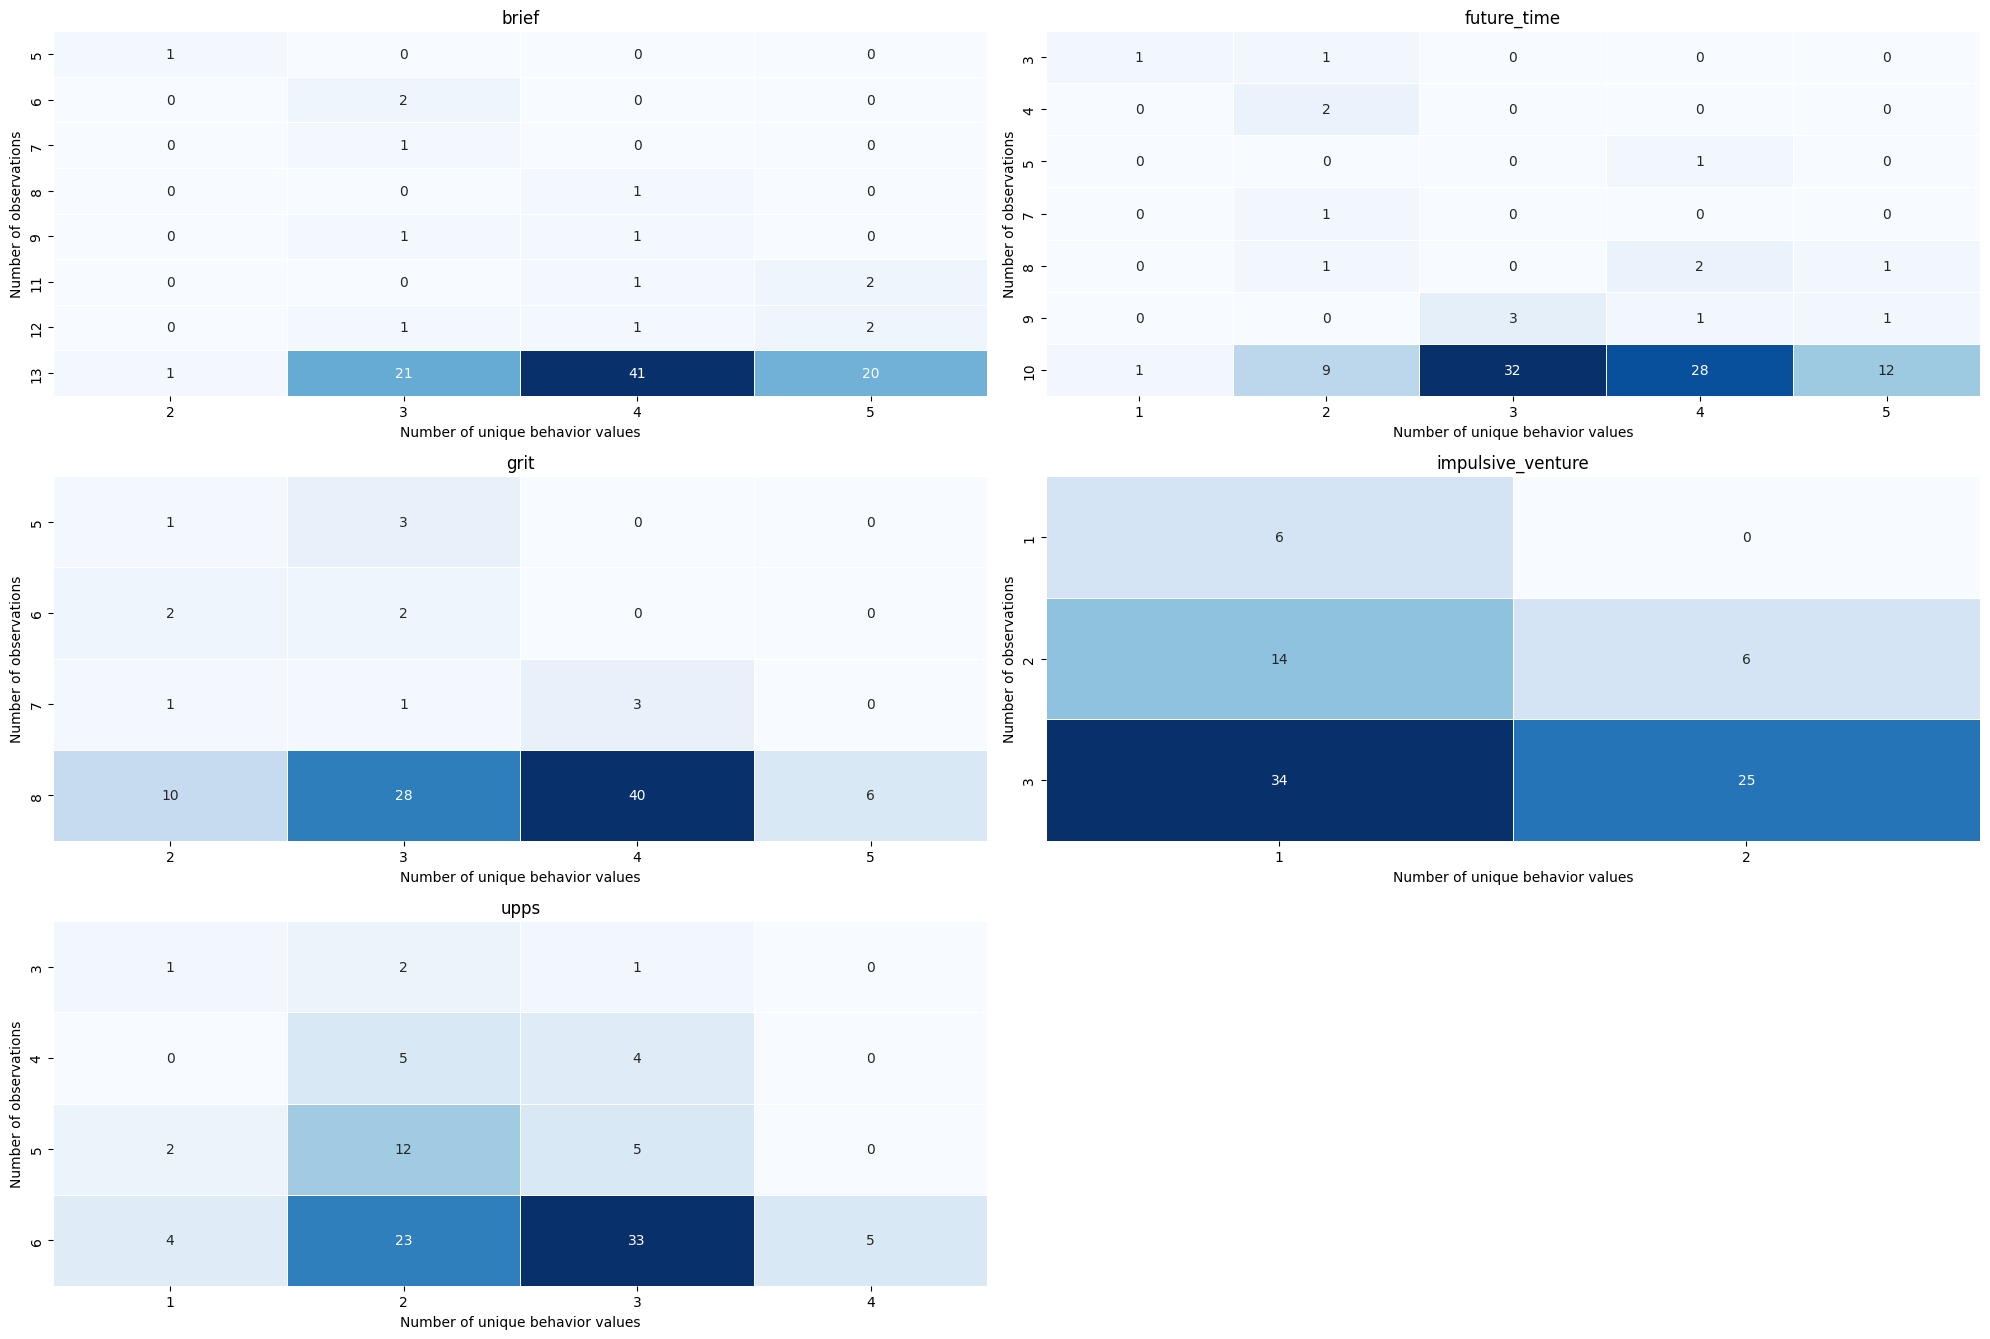

In [8]:
import math

# Summarize per subject within questionnaire
subject_counts = (
    all_dat_df.groupby(['questionnaire', 'subid'])
    .agg(
        n_obs=('behav_value', 'size'),
        n_unique_behav=('behav_value', 'nunique'),
    )
    .reset_index()
)

questionnaire_list = sorted(subject_counts['questionnaire'].unique())
n_panels = len(questionnaire_list)
ncols = 2
nrows = math.ceil(n_panels / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10 * ncols, 4.5 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, questionnaire in zip(axes, questionnaire_list):
    subset = subject_counts[subject_counts['questionnaire'] == questionnaire]
    table_df = pd.crosstab(subset['n_obs'], subset['n_unique_behav'])
    sns.heatmap(
        table_df,
        ax=ax,
        cmap='Blues',
        annot=True,
        fmt='d',
        cbar=False,
        linewidths=0.5,
        linecolor='white',
    )
    ax.set_title(questionnaire)
    ax.set_xlabel('Number of unique behavior values')
    ax.set_ylabel('Number of observations')

# Hide any unused axes
for ax in axes[n_panels:]:
    ax.axis('off')

plt.tight_layout()

### Special case when there are only 2 unique behavioral values
The below table illustrates, by questionnaire, how many subjects (cell counts) there are with only 2 unique behavioral values each with (#obs1, #obs2) observations on the x-axis (e.g., (1, 2) means one behavioral measure has 1 observation associated with it while the other has 2).  In our second, secondary analysis we only allow cases where the tuple values are both 2 or larger.

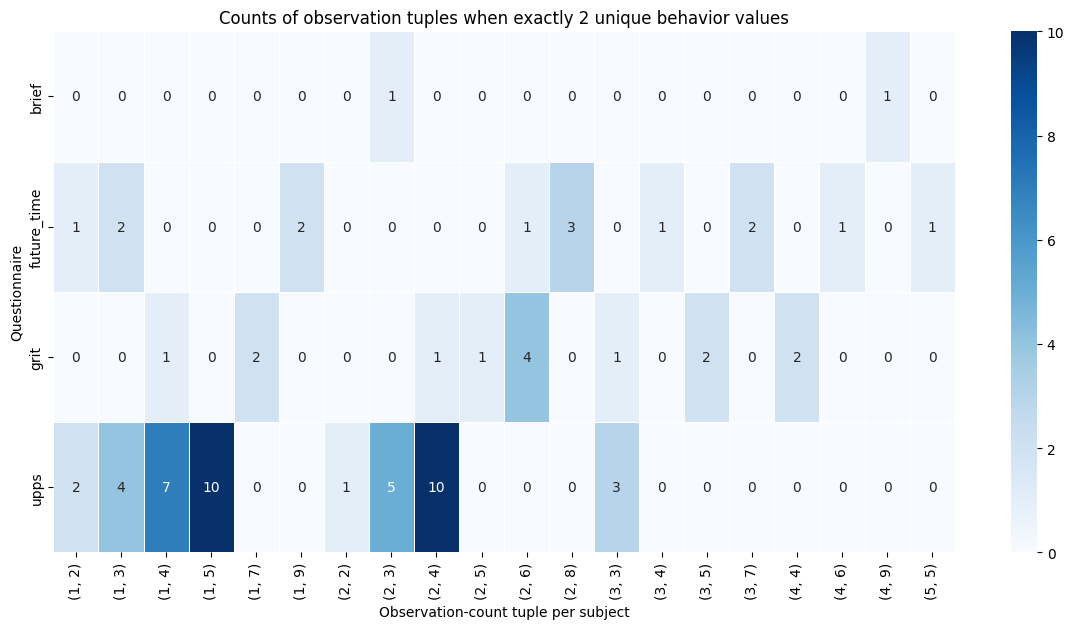

In [9]:
# Heatmap of 2-unique-value tuple counts per questionnaire
per_value_counts = (
    all_dat_df.groupby(['questionnaire', 'subid', 'behav_value'])
    .size()
    .rename('value_count')
    .reset_index()
)

subject_value_counts = (
    per_value_counts.groupby(['questionnaire', 'subid'])
    .agg(
        n_unique=('behav_value', 'nunique'),
        counts_tuple=('value_count', lambda x: tuple(sorted(x.tolist()))),
    )
    .reset_index()
)

binary_subjects = subject_value_counts[subject_value_counts['n_unique'] == 2].copy()
binary_subjects = binary_subjects[
    binary_subjects['questionnaire'] != 'impulsive_venture'
]
binary_subjects['counts_tuple_str'] = binary_subjects['counts_tuple'].apply(
    lambda x: str(x)
)

tuple_table = pd.crosstab(
    binary_subjects['questionnaire'],
    binary_subjects['counts_tuple_str'],
)

plt.figure(figsize=(12, 4 + 0.6 * len(tuple_table.index)))
sns.heatmap(
    tuple_table,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=0.5,
    linecolor='white',
)
plt.title('Counts of observation tuples when exactly 2 unique behavior values')
plt.xlabel('Observation-count tuple per subject')
plt.ylabel('Questionnaire')
plt.tight_layout()

### Sample sizes for each slope using the three omission criteria

Everything checks out with what Jaemon printed in his notebook.

In [10]:
# min_obs_6_min_unique_3_min_obs_binary_None

# Per-questionnaire subject inclusion/exclusion under criteria
from IPython.display import display

criteria = (subject_counts['n_obs'] >= 6) & (subject_counts['n_unique_behav'] >= 3)
subject_counts = subject_counts.assign(is_eligible=criteria)

questionnaire_subject_summary = (
    subject_counts.groupby('questionnaire')
    .agg(
        total_subjects=('subid', 'nunique'),
        included_subjects=('is_eligible', 'sum'),
    )
    .reset_index()
)
questionnaire_subject_summary['excluded_subjects'] = (
    questionnaire_subject_summary['total_subjects']
    - questionnaire_subject_summary['included_subjects']
)

styled = questionnaire_subject_summary.style.set_caption(
    'min_obs_6_min_unique_3_min_obs_binary_None'
).set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold')]}]
)
display(styled)

,questionnaire,total_subjects,included_subjects,excluded_subjects
0,brief,97,95,2
1,future_time,97,80,17
2,grit,97,80,17
3,impulsive_venture,85,0,85
4,upps,97,38,59


In [11]:
# min_obs_5_min_unique_3_min_obs_binary_None

# Per-questionnaire subject inclusion/exclusion under criteria
criteria = (subject_counts['n_obs'] >= 5) & (subject_counts['n_unique_behav'] >= 3)
subject_counts = subject_counts.assign(is_eligible=criteria)

questionnaire_subject_summary = (
    subject_counts.groupby('questionnaire')
    .agg(
        total_subjects=('subid', 'nunique'),
        included_subjects=('is_eligible', 'sum'),
    )
    .reset_index()
)
questionnaire_subject_summary['excluded_subjects'] = (
    questionnaire_subject_summary['total_subjects']
    - questionnaire_subject_summary['included_subjects']
)

styled = questionnaire_subject_summary.style.set_caption(
    'min_obs_5_min_unique_3_min_obs_binary_None'
).set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold')]}]
)
display(styled)

,questionnaire,total_subjects,included_subjects,excluded_subjects
0,brief,97,95,2
1,future_time,97,81,16
2,grit,97,83,14
3,impulsive_venture,85,0,85
4,upps,97,43,54


In [12]:
# min_obs_5_min_unique_3_min_obs_binary_2

# Per-questionnaire subject inclusion/exclusion with conditional per-value minimum counts
from IPython.display import display

per_value_counts = (
    all_dat_df.groupby(['questionnaire', 'subid', 'behav_value'])
    .size()
    .rename('value_count')
    .reset_index()
)

subject_value_summary = (
    per_value_counts.groupby(['questionnaire', 'subid'])
    .agg(
        n_obs=('value_count', 'sum'),
        n_unique_behav=('behav_value', 'nunique'),
        min_per_value=('value_count', 'min'),
    )
    .reset_index()
)

criteria_conditional = (subject_value_summary['n_obs'] >= 5) & (
    (subject_value_summary['n_unique_behav'] >= 3)
    | (
        (subject_value_summary['n_unique_behav'] == 2)
        & (subject_value_summary['min_per_value'] >= 2)
    )
)
subject_value_summary = subject_value_summary.assign(is_eligible=criteria_conditional)

questionnaire_subject_summary_conditional = (
    subject_value_summary.groupby('questionnaire')
    .agg(
        total_subjects=('subid', 'nunique'),
        included_subjects=('is_eligible', 'sum'),
    )
    .reset_index()
)
questionnaire_subject_summary_conditional['excluded_subjects'] = (
    questionnaire_subject_summary_conditional['total_subjects']
    - questionnaire_subject_summary_conditional['included_subjects']
)

styled = questionnaire_subject_summary_conditional.style.set_caption(
    'min_obs_5_min_unique_3_min_obs_binary_2'
).set_table_styles(
    [{'selector': 'caption', 'props': [('font-size', '18px'), ('font-weight', 'bold')]}]
)
display(styled)

,questionnaire,total_subjects,included_subjects,excluded_subjects
0,brief,97,97,0
1,future_time,97,90,7
2,grit,97,94,3
3,impulsive_venture,85,0,85
4,upps,97,61,36


## Final sample sizes including exclusion of slope outliers

### Figure to display Jaemon's `group_model_inclusion.csv`

I've realized I misinterpreted the meaning of this csv, so Jaemon is recoding it.  Until then, I'll reshape this into the version he'll be recreating....

In [13]:
data_root = (
    cfg.output_root
    / 'within_subject_brain_behavior_by_questionnaire/within_subject_results'
)
exclusion_file = data_root / 'group_model_inclusion.csv'
exclusion = pd.read_csv(exclusion_file)

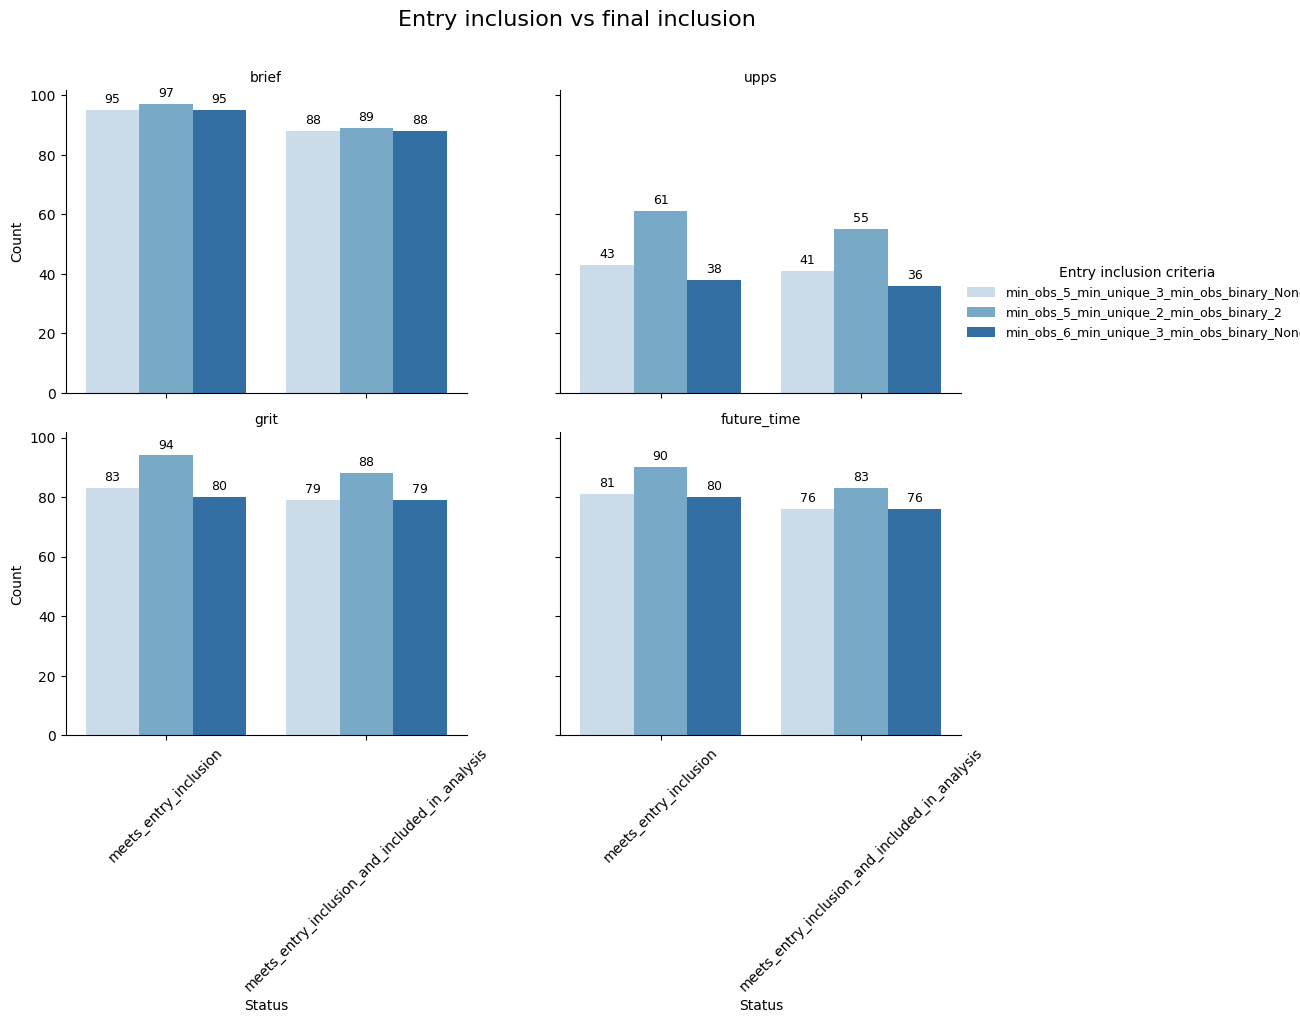

In [14]:
df = exclusion.copy()

# Build a long-format dataframe for plotting two sets of bars per subject
plot_df = pd.DataFrame(
    {
        'sub_id': pd.concat([df['sub_id'], df['sub_id']]),
        'questionnaire': pd.concat([df['questionnaire'], df['questionnaire']]),
        'entry_inclusion_criteria': pd.concat(
            [df['entry_inclusion_criteria'], df['entry_inclusion_criteria']]
        ),
        'status': ['meets_entry_inclusion'] * len(df)
        + ['meets_entry_inclusion_and_included_in_analysis'] * len(df),
    }
)

# Add a column to filter which subjects count in each status
plot_df['count_flag'] = pd.concat(
    [
        df['meets_entry_inclusion_criteria'],  # first bar: all who meet entry inclusion
        df['meets_entry_inclusion_criteria']
        & df['include_in_analysis'],  # second bar: subset included in analysis
    ]
)

# Keep only rows that count
plot_df = plot_df[plot_df['count_flag']]

# Plot
palette = sns.color_palette('Blues', n_colors=df['entry_inclusion_criteria'].nunique())
status_order = [
    'meets_entry_inclusion',
    'meets_entry_inclusion_and_included_in_analysis',
]


g = sns.catplot(
    data=plot_df,
    kind='count',
    x='status',
    hue='entry_inclusion_criteria',
    col='questionnaire',
    col_wrap=2,
    height=4,
    aspect=1.2,
    palette=palette,
    order=status_order,
)

g.fig.set_size_inches(12, 8)  # width x height

# Adjust spacing to leave room for legend
g.fig.subplots_adjust(top=0.88, right=0.85)


# Labels and titles
g.set_axis_labels('Status', 'Count')
g.set_titles('{col_name}')

g.fig.subplots_adjust(top=0.88, right=0.82)
g.fig.suptitle('Entry inclusion vs final inclusion', fontsize=16)

# Legend formatting
legend = g._legend
legend.set_title('Entry inclusion criteria')
legend.set_bbox_to_anchor((1.1, 0.9))
legend.set_frame_on(False)

for text in legend.get_texts():
    text.set_fontsize(9)
legend.get_title().set_fontsize(10)

# Add bar labels
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45)
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

plt.show()

## summarizing `subject_slope_contrasts.py`

These are the exact functions used in Jaemmon's slope estimation code (so slope outliers have not yet been determined)

In [15]:
from subject_slope_contrasts import (
    apply_inclusion_criteria,
    build_design_matrix_contrasts,
    define_questionnaires,
    get_behavior_bold_data,
)

In [16]:
root = cfg.data_root
questionnaires = define_questionnaires()
events_files = sorted(
    glob.glob(f'{root}/BIDS/sub-s*/ses-[0-9]/func/*surveyMedley*modified*.tsv')
)
activation_maps = glob.glob(f'{question_output_path}/*/*.nii.gz')

model_settings = [
    {'min_obs': 5, 'min_unique': 3, 'min_obs_per_level_when_binary': None},
    {'min_obs': 5, 'min_unique': 2, 'min_obs_per_level_when_binary': 2},
    {'min_obs': 6, 'min_unique': 3, 'min_obs_per_level_when_binary': None},
]

all_desmats = []
all_subids = []
all_contrast_names = []
all_model_settings = []

rows = []
for subid in subids:
    subid_clean = subid[1:] if str(subid).startswith('s') else str(subid)
    try:
        behav_df = get_behavior_bold_data(
            subid_clean,
            events_files,
            questionnaires,
            question_output_path,
            activation_maps,
        )
    except Exception as e:
        print(f'Error loading data for subid {subid}: {e}')
        continue

    if behav_df.empty:
        print(f'No data for subid {subid}')
        continue

    for setting in model_settings:
        try:
            filtered = apply_inclusion_criteria(
                behav_df.copy(),
                questionnaires,
                min_obs=setting['min_obs'],
                min_unique=setting['min_unique'],
                min_obs_per_level_when_binary=setting['min_obs_per_level_when_binary'],
            )

        except Exception as e:
            print(f'Error applying criteria for subid {subid}: {e}')
            continue

        design_matrix, sub_bold_files, contrast_names = build_design_matrix_contrasts(
            filtered
        )
        all_subids.append(subid_clean)
        all_desmats.append(design_matrix)
        all_contrast_names.append(contrast_names)
        all_model_settings.append(
            f'min_obs_{setting["min_obs"]}_min_unique_{setting["min_unique"]}_min_obs_binary_{setting["min_obs_per_level_when_binary"]}'
        )

        included_questionnaires = set(filtered['questionnaire_name'].unique())
        for questionnaire in questionnaires.keys():
            if questionnaire in included_questionnaires:
                rows.append(
                    {
                        'subid': subid_clean,
                        'questionnaire': questionnaire,
                        'min_obs': setting['min_obs'],
                        'min_unique': setting['min_unique'],
                        'min_obs_per_level_when_binary': setting[
                            'min_obs_per_level_when_binary'
                        ],
                    }
                )

processing grit
processing brief
processing future_time
processing upps
processing impulsive_venture
processing grit
processing brief
processing future_time
processing upps
processing impulsive_venture
processing grit
processing brief
processing future_time
processing upps
processing impulsive_venture
processing grit
processing brief
processing future_time
processing upps
processing impulsive_venture
processing grit
processing brief
processing future_time
processing upps
processing impulsive_venture
processing grit
processing brief
processing future_time
processing upps
processing impulsive_venture
Error loading data for subid s144: Invalid file path or buffer object type: <class 'NoneType'>
processing grit
processing brief
processing future_time
processing upps
processing impulsive_venture
processing grit
processing brief
processing future_time
processing upps
processing impulsive_venture
processing grit
processing brief
processing future_time
processing upps
processing impulsive_vent

### The output below matches the barplots above, so everything matches up!

In [17]:
summary_df = pd.DataFrame(rows)

if summary_df.empty:
    sample_size_by_model = summary_df
else:
    summary_df = summary_df.assign(
        min_obs_per_level_when_binary_label=summary_df[
            'min_obs_per_level_when_binary'
        ].fillna('none')
    )
    summary_df['inclusion_criteria'] = (
        'min_obs_'
        + summary_df['min_obs'].astype(str)
        + '_min_unique_behav_'
        + summary_df['min_unique'].astype(str)
        + '_min_obs_per_level_when_binary_'
        + summary_df['min_obs_per_level_when_binary_label'].astype(str)
    )
    sample_size_by_model = (
        summary_df.groupby(['questionnaire', 'inclusion_criteria'])
        .agg(n_subjects=('subid', 'nunique'))
        .reset_index()
    )
sample_size_by_model

,questionnaire,inclusion_criteria,n_subjects
0,brief,min_obs_5_min_unique_behav_2_min_obs_per_level...,97
1,brief,min_obs_5_min_unique_behav_3_min_obs_per_level...,95
2,brief,min_obs_6_min_unique_behav_3_min_obs_per_level...,95
3,future_time,min_obs_5_min_unique_behav_2_min_obs_per_level...,90
4,future_time,min_obs_5_min_unique_behav_3_min_obs_per_level...,81
5,future_time,min_obs_6_min_unique_behav_3_min_obs_per_level...,80
6,grit,min_obs_5_min_unique_behav_2_min_obs_per_level...,94
7,grit,min_obs_5_min_unique_behav_3_min_obs_per_level...,83
8,grit,min_obs_6_min_unique_behav_3_min_obs_per_level...,80
9,upps,min_obs_5_min_unique_behav_2_min_obs_per_level...,61


### Check out design matrix structure for a few subjects

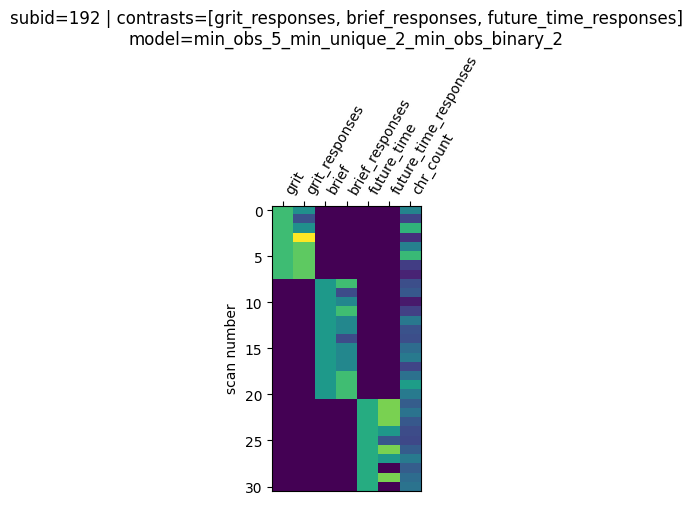

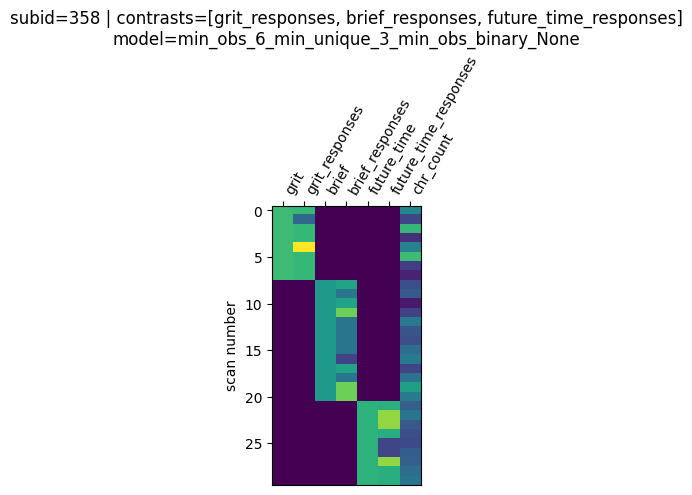

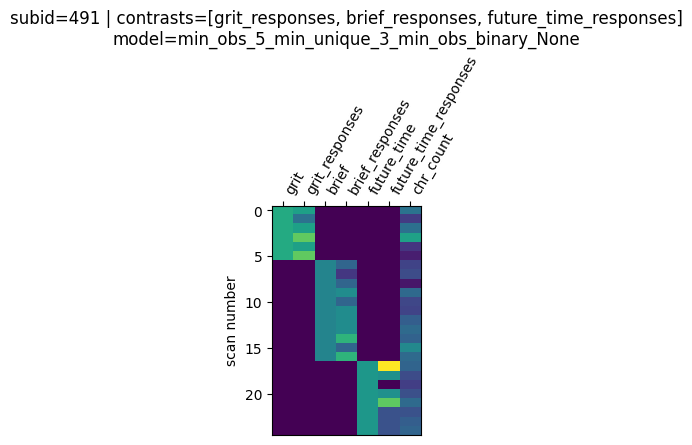

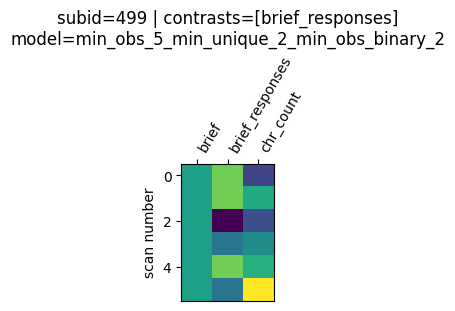

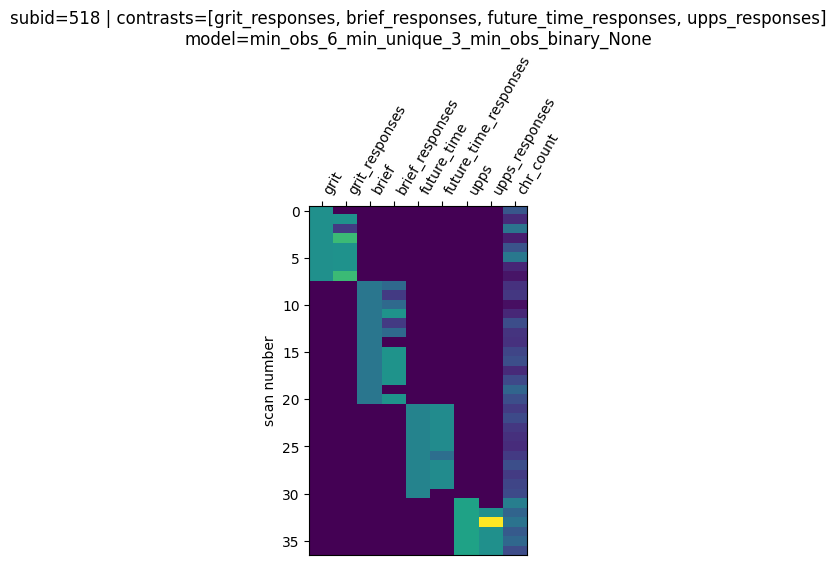

In [18]:
# Plot selected design matrices with subject + contrast names in title
indices_to_plot = [10, 20, 30, 40, 50]

for idx in indices_to_plot:
    if idx >= len(all_desmats):
        print(
            f'Skipping index {idx}: out of range for all_desmats (n={len(all_desmats)})'
        )
        continue
    desmat = all_desmats[idx]
    subid = all_subids[idx] if idx < len(all_subids) else 'unknown_subid'
    contrast_names = all_contrast_names[idx] if idx < len(all_contrast_names) else []
    model_setting = (
        all_model_settings[idx] if idx < len(all_model_settings) else 'unknown_model'
    )
    contrast_label = ', '.join(map(str, contrast_names))
    plot_design_matrix(desmat)
    plt.title(f'subid={subid} | contrasts=[{contrast_label}]\nmodel={model_setting}')
    plt.show()

In [19]:
# Build per-questionnaire std summaries from design matrices
std_data = {
    'subids': [],
    'model_settings': [],
    'std': [],
    'questionnaire': [],
    'contrast_names': [],
    'n_obs': [],
}

for idx, desmat in enumerate(all_desmats):
    subid = all_subids[idx]
    model_setting = all_model_settings[idx]
    contrast_names = all_contrast_names[idx]

    response_cols = [c for c in desmat.columns if c.endswith('_responses')]
    for response_col in response_cols:
        base_col = response_col.replace('_responses', '')
        if base_col not in desmat.columns:
            continue
        mask = desmat[base_col] == 1
        values = desmat.loc[mask, response_col].dropna()
        std_val = values.std(ddof=1) if len(values) > 1 else np.nan

        std_data['subids'].append(subid)
        std_data['model_settings'].append(model_setting)
        std_data['std'].append(std_val)
        std_data['questionnaire'].append(base_col)
        std_data['contrast_names'].append(contrast_names)
        std_data['n_obs'].append(int(values.shape[0]))

std_data_df = pd.DataFrame(std_data)


In [20]:
std_data_df

,subids,model_settings,std,questionnaire,contrast_names,n_obs
0,061,min_obs_5_min_unique_3_min_obs_binary_None,0.176777,grit,"[grit_responses, brief_responses]",5
1,061,min_obs_5_min_unique_3_min_obs_binary_None,0.223607,brief,"[grit_responses, brief_responses]",6
2,061,min_obs_5_min_unique_2_min_obs_binary_2,0.176777,grit,"[grit_responses, brief_responses]",5
3,061,min_obs_5_min_unique_2_min_obs_binary_2,0.223607,brief,"[grit_responses, brief_responses]",6
4,061,min_obs_6_min_unique_3_min_obs_binary_None,0.223607,brief,[brief_responses],6
...,...,...,...,...,...,...
932,650,min_obs_5_min_unique_2_min_obs_binary_2,0.176777,brief,"[grit_responses, brief_responses, future_time_...",9
933,650,min_obs_5_min_unique_2_min_obs_binary_2,0.242956,future_time,"[grit_responses, brief_responses, future_time_...",10
934,650,min_obs_6_min_unique_3_min_obs_binary_None,0.345033,grit,"[grit_responses, brief_responses, future_time_...",7
935,650,min_obs_6_min_unique_3_min_obs_binary_None,0.176777,brief,"[grit_responses, brief_responses, future_time_...",9


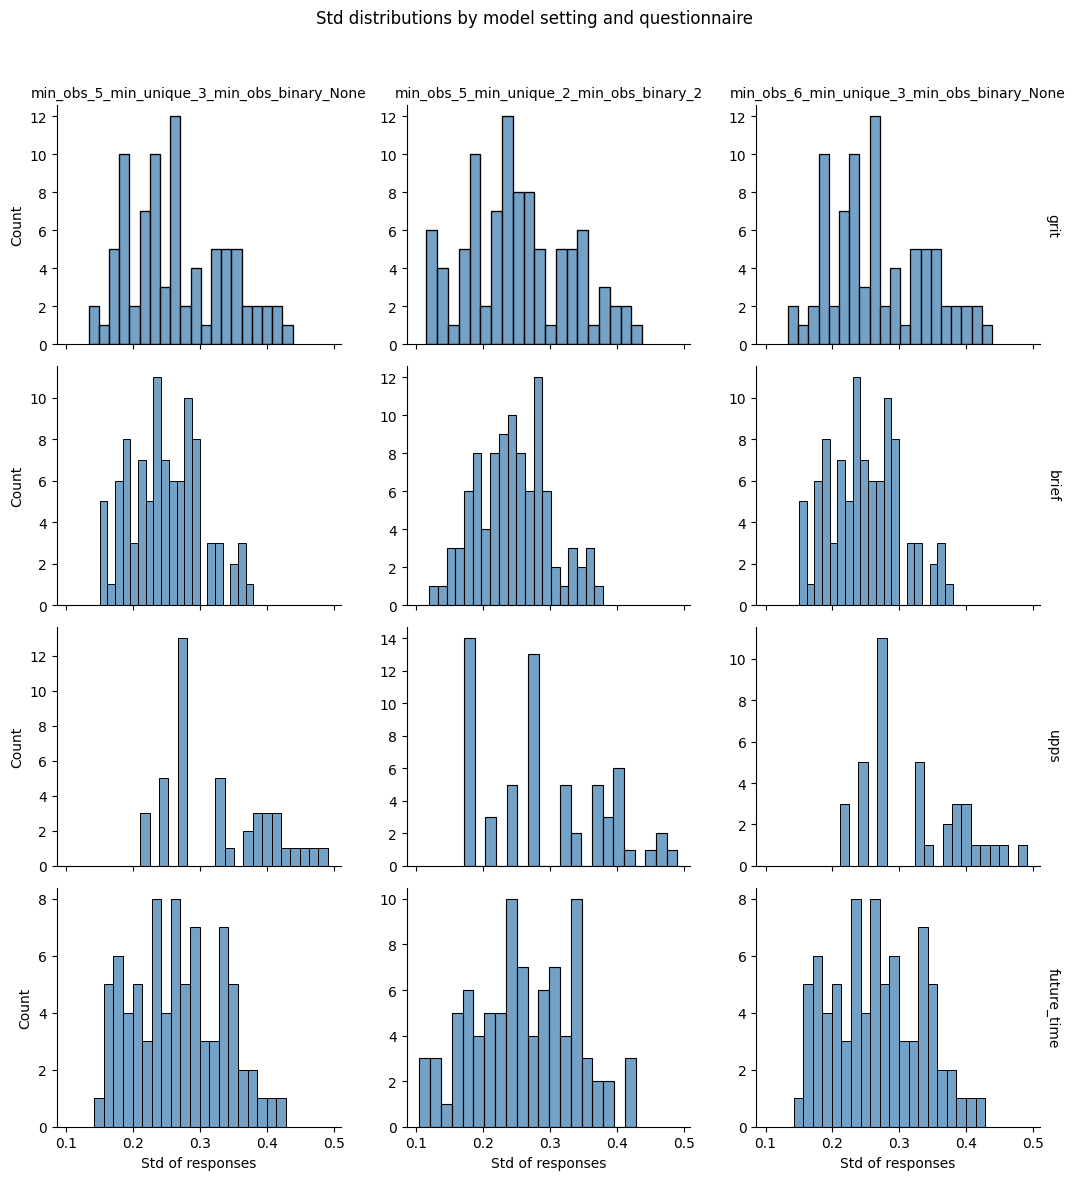

In [21]:
# Histogram grid of stds by model setting (rows) and questionnaire (cols)
std_plot_df = std_data_df.dropna(subset=['std']).copy()

model_order = list(dict.fromkeys(std_plot_df['model_settings']))
questionnaire_order = list(dict.fromkeys(std_plot_df['questionnaire']))

g = sns.FacetGrid(
    std_plot_df,
    col='model_settings',
    row='questionnaire',
    row_order=questionnaire_order,
    col_order=model_order,
    height=3,
    aspect=1.2,
    sharex=True,
    sharey=False,
    margin_titles=True,
)
g.map_dataframe(sns.histplot, x='std', bins=20, color='steelblue')
g.set_axis_labels('Std of responses', 'Count')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
g.fig.subplots_adjust(top=0.9)
g.fig.suptitle('Std distributions by model setting and questionnaire')
plt.show()